# PX4 Phase 1 Closed-Loop PINN-MPC v2 Position State

This notebook uses the trained v17 position-state closed-loop dynamics PINN as the prediction model for an upper-level MPC.

The MPC optimizes PX4 offboard-style setpoints:

- local position setpoint: north/east/down
- local velocity setpoint: north/east/down
- yaw setpoint and yaw-offset setpoint

The important v2 change is that the learned state contains `local_north_m` and `local_east_m`. The optimizer therefore tracks predicted position directly instead of relying on an external velocity integrator.


In [5]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as exc:
    print('Drive mount skipped:', type(exc).__name__, exc)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import glob
import json
import math
import os
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('torch:', torch.__version__)


device: cuda
torch: 2.10.0+cu128


In [7]:
NOTEBOOK_REVISION = 'v2_position_state_pinn_mpc'
MANUAL_CHECKPOINT_PATH = ''  # Set manually if auto-search misses it.
CHECKPOINT_GLOBS = [
    '/content/drive/MyDrive/Colab Result/PINN_MPC/px4_phase1_closed_loop_position_state_training_v17/**/px4_closed_loop_position_state_dynamics_pinn_v17.pt',
    '/content/drive/MyDrive/**/px4_closed_loop_position_state_dynamics_pinn_v17.pt',
    '/content/**/px4_closed_loop_position_state_dynamics_pinn_v17.pt',
]

DT = 0.05
MPC_HORIZON = 60          # 3 seconds at 20 Hz
MPC_SAMPLES = 768         # works on T4; reduce to 128 on CPU
MPC_ELITES = 64
MPC_ITERS = 5
CONTROL_INTERVAL_STEPS = 4  # apply first 0.2 s of optimized sequence

# Setpoint bounds. Position references are local NED offsets around hover.
POS_LIMIT_M = 4.5
ALT_MIN_M = 18.0
ALT_MAX_M = 32.0
VEL_LIMIT_M_S = 0.55
VD_LIMIT_M_S = 0.30
YAW_OFFSET_LIMIT_DEG = 30.0
DELTA_POS_LIMIT_M = 0.35
DELTA_VEL_LIMIT_M_S = 0.15
DELTA_YAW_LIMIT_DEG = 4.0

COST = dict(
    pos=20.0,
    alt=24.0,
    vel=1.4,
    yaw=2.0,
    terminal_pos=55.0,
    terminal_alt=60.0,
    attitude=0.08,
    safety=150.0,
    effort_pos=0.02,
    effort_vel=0.08,
    effort_yaw=0.02,
    smooth=0.12,
)


In [8]:
def find_checkpoint():
    if MANUAL_CHECKPOINT_PATH:
        p = Path(MANUAL_CHECKPOINT_PATH)
        if p.exists():
            return p
        raise FileNotFoundError(f'MANUAL_CHECKPOINT_PATH not found: {p}')
    matches = []
    for pat in CHECKPOINT_GLOBS:
        matches.extend(Path(x) for x in glob.glob(pat, recursive=True))
    matches = sorted(set(p for p in matches if p.exists()))
    if not matches:
        raise FileNotFoundError('No v17 position-state PINN checkpoint found. Run the v17 position-state training notebook first or set MANUAL_CHECKPOINT_PATH.')
    return matches[-1]

CKPT_PATH = find_checkpoint()
print('CKPT_PATH:', CKPT_PATH)
ckpt = torch.load(CKPT_PATH, map_location='cpu', weights_only=False)
print('revision:', ckpt.get('revision'))
print('dataset:', ckpt.get('dataset_dir'))
STATE_COLS = ckpt['state_cols']
ACTION_COLS = ckpt['action_cols']
TARGET_COLS = ckpt['target_cols']
FEATURE_COLS = ckpt['feature_cols']
print('state:', STATE_COLS)
print('action:', ACTION_COLS)
print('feature dim:', len(FEATURE_COLS))

required_state = {'local_north_m', 'local_east_m', 'relative_altitude_m', 'yaw_deg'}
missing_state = sorted(required_state - set(STATE_COLS))
if missing_state:
    raise ValueError(f'This v2 MPC requires a position-state checkpoint. Missing state columns: {missing_state}')


CKPT_PATH: /content/drive/MyDrive/Colab Result/PINN_MPC/px4_phase1_closed_loop_position_state_training_v17/20260509_232358/px4_closed_loop_position_state_dynamics_pinn_v17.pt
revision: v17_position_state
dataset: /content/drive/MyDrive/px4_datasets/processed/px4_phase1_closed_loop_yawrel_position_state_dataset_v8_20260510_081623
state: ['local_north_m', 'local_east_m', 'relative_altitude_m', 'vel_north_m_s', 'vel_east_m_s', 'vel_down_m_s', 'roll_deg', 'pitch_deg', 'yaw_deg', 'roll_rate_rad_s', 'pitch_rate_rad_s', 'yaw_rate_rad_s']
action: ['ref_north_m', 'ref_east_m', 'ref_down_m', 'ref_north_m_s', 'ref_east_m_s', 'ref_down_m_s', 'ref_yaw_deg', 'ref_yaw_offset_deg']
feature dim: 40


In [9]:
class ResidualMLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=256, depth=4, dropout=0.03):
        super().__init__()
        layers = []
        d = in_dim
        for _ in range(depth):
            layers += [nn.Linear(d, hidden), nn.LayerNorm(hidden), nn.SiLU(), nn.Dropout(dropout)]
            d = hidden
        layers.append(nn.Linear(d, out_dim))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

class Scaler:
    def __init__(self, payload):
        self.mean = torch.tensor(payload['mean'], dtype=torch.float32)
        self.std = torch.tensor(payload['std'], dtype=torch.float32).clamp_min(1e-8)
    def encode(self, x):
        return (torch.as_tensor(x, dtype=torch.float32) - self.mean) / self.std
    def decode(self, z):
        return z * self.std.to(z.device) + self.mean.to(z.device)

model_cfg = ckpt.get('model_config', {})
model = ResidualMLP(
    len(FEATURE_COLS), len(TARGET_COLS),
    hidden=int(model_cfg.get('hidden', 256)),
    depth=int(model_cfg.get('depth', 4)),
    dropout=float(model_cfg.get('dropout', 0.0)),
).to(device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
x_scaler = Scaler(ckpt['x_scaler'])
y_scaler = Scaler(ckpt['y_scaler'])
state_index = {c: i for i, c in enumerate(STATE_COLS)}
target_index = {c: i for i, c in enumerate(TARGET_COLS)}
feature_index = {c: i for i, c in enumerate(FEATURE_COLS)}


In [10]:
def wrap_deg_np(x):
    return ((x + 180.0) % 360.0) - 180.0

def build_feature_matrix(states, actions, prev_actions, dt=DT):
    states = np.asarray(states, dtype=np.float32)
    actions = np.asarray(actions, dtype=np.float32)
    prev_actions = np.asarray(prev_actions, dtype=np.float32)
    if states.ndim == 1:
        states = states[None, :]
    if actions.ndim == 1:
        actions = actions[None, :]
    if prev_actions.ndim == 1:
        prev_actions = prev_actions[None, :]
    du = actions - prev_actions
    n = states.shape[0]
    cols = []
    for name in FEATURE_COLS:
        if name == 'dt_s':
            cols.append(np.full(n, dt, dtype=np.float32))
        elif name == 'x_yaw_sin':
            cols.append(np.sin(np.deg2rad(states[:, state_index['yaw_deg']])))
        elif name == 'x_yaw_cos':
            cols.append(np.cos(np.deg2rad(states[:, state_index['yaw_deg']])))
        elif name.startswith('x_'):
            col = name[2:]
            cols.append(states[:, state_index[col]])
        elif name.startswith('u_') and name.endswith('_sin'):
            col = name[2:-4]
            cols.append(np.sin(np.deg2rad(actions[:, ACTION_COLS.index(col)])))
        elif name.startswith('u_') and name.endswith('_cos'):
            col = name[2:-4]
            cols.append(np.cos(np.deg2rad(actions[:, ACTION_COLS.index(col)])))
        elif name.startswith('prev_u_') and name.endswith('_sin'):
            col = name[7:-4]
            cols.append(np.sin(np.deg2rad(prev_actions[:, ACTION_COLS.index(col)])))
        elif name.startswith('prev_u_') and name.endswith('_cos'):
            col = name[7:-4]
            cols.append(np.cos(np.deg2rad(prev_actions[:, ACTION_COLS.index(col)])))
        elif name.startswith('u_'):
            col = name[2:]
            cols.append(actions[:, ACTION_COLS.index(col)])
        elif name.startswith('prev_u_'):
            col = name[7:]
            cols.append(prev_actions[:, ACTION_COLS.index(col)])
        elif name.startswith('du_'):
            col = name[3:]
            vals = du[:, ACTION_COLS.index(col)]
            if col in ['ref_yaw_deg', 'ref_yaw_offset_deg']:
                vals = wrap_deg_np(vals)
            cols.append(vals)
        else:
            raise KeyError(f'Unsupported feature name: {name}')
    return np.stack(cols, axis=1).astype(np.float32)

@torch.no_grad()
def predict_delta(states, actions, prev_actions, dt=DT):
    X = build_feature_matrix(states, actions, prev_actions, dt)
    Xz = x_scaler.encode(X).to(device)
    dz = model(Xz)
    dy = y_scaler.decode(dz).cpu().numpy()
    return dy

def step_model(states, actions, prev_actions, dt=DT):
    dx = predict_delta(states, actions, prev_actions, dt)
    next_states = np.asarray(states, dtype=np.float32).copy() + dx.astype(np.float32)
    next_states[:, state_index['yaw_deg']] = wrap_deg_np(next_states[:, state_index['yaw_deg']])
    return next_states


In [11]:
def make_action(ref_n=0.0, ref_e=0.0, ref_alt=25.0, ref_vn=0.0, ref_ve=0.0, ref_vd=0.0, yaw_base_deg=90.0, yaw_offset_deg=0.0):
    # ref_down_m is NED down, so altitude 25 m -> down -25 m.
    values = {
        'ref_north_m': ref_n,
        'ref_east_m': ref_e,
        'ref_down_m': -ref_alt,
        'ref_north_m_s': ref_vn,
        'ref_east_m_s': ref_ve,
        'ref_down_m_s': ref_vd,
        'ref_yaw_deg': wrap_deg_np(yaw_base_deg + yaw_offset_deg),
        'ref_yaw_offset_deg': yaw_offset_deg,
    }
    return np.asarray([values[c] for c in ACTION_COLS], dtype=np.float32)

def clip_actions(actions, yaw_base_deg=90.0):
    a = np.asarray(actions, dtype=np.float32).copy()
    def col(name): return ACTION_COLS.index(name)
    a[..., col('ref_north_m')] = np.clip(a[..., col('ref_north_m')], -POS_LIMIT_M, POS_LIMIT_M)
    a[..., col('ref_east_m')] = np.clip(a[..., col('ref_east_m')], -POS_LIMIT_M, POS_LIMIT_M)
    alt = -a[..., col('ref_down_m')]
    alt = np.clip(alt, ALT_MIN_M, ALT_MAX_M)
    a[..., col('ref_down_m')] = -alt
    a[..., col('ref_north_m_s')] = np.clip(a[..., col('ref_north_m_s')], -VEL_LIMIT_M_S, VEL_LIMIT_M_S)
    a[..., col('ref_east_m_s')] = np.clip(a[..., col('ref_east_m_s')], -VEL_LIMIT_M_S, VEL_LIMIT_M_S)
    a[..., col('ref_down_m_s')] = np.clip(a[..., col('ref_down_m_s')], -VD_LIMIT_M_S, VD_LIMIT_M_S)
    a[..., col('ref_yaw_offset_deg')] = np.clip(a[..., col('ref_yaw_offset_deg')], -YAW_OFFSET_LIMIT_DEG, YAW_OFFSET_LIMIT_DEG)
    a[..., col('ref_yaw_deg')] = wrap_deg_np(yaw_base_deg + a[..., col('ref_yaw_offset_deg')])
    return a

def action_sequence_from_nominal(nominal_action, horizon=MPC_HORIZON, samples=MPC_SAMPLES, std_scale=1.0, yaw_base_deg=90.0):
    seq = np.repeat(nominal_action[None, None, :], samples * horizon, axis=0).reshape(samples, horizon, -1)
    noise = np.zeros_like(seq)
    for name, sigma in [
        ('ref_north_m', 0.42), ('ref_east_m', 0.42), ('ref_down_m', 0.25),
        ('ref_north_m_s', 0.08), ('ref_east_m_s', 0.08), ('ref_down_m_s', 0.05),
        ('ref_yaw_offset_deg', 2.2),
    ]:
        noise[..., ACTION_COLS.index(name)] = np.random.normal(0.0, sigma * std_scale, size=(samples, horizon))
    seq = seq + np.cumsum(noise, axis=1) * 0.10
    seq[:, 0, :] = nominal_action
    return clip_actions(seq, yaw_base_deg=yaw_base_deg)


In [12]:
def target_at_time(t):
    # Mission-style local task within the v14/v15 closed-loop data envelope.
    if t < 3.0:
        return dict(n=0.0, e=0.0, alt=25.0, yaw_offset=0.0)
    if t < 7.0:
        return dict(n=1.5, e=1.0, alt=26.5, yaw_offset=8.0)
    if t < 11.0:
        return dict(n=-1.0, e=-1.0, alt=24.0, yaw_offset=-8.0)
    return dict(n=0.0, e=0.0, alt=25.0, yaw_offset=0.0)

def trajectory_targets(times):
    return [target_at_time(float(t)) for t in times]

def running_cost(states, actions, prev_actions, targets, yaw_base_deg=90.0):
    north = states[:, state_index['local_north_m']]
    east = states[:, state_index['local_east_m']]
    alt = states[:, state_index['relative_altitude_m']]
    vn = states[:, state_index['vel_north_m_s']]
    ve = states[:, state_index['vel_east_m_s']]
    vd = states[:, state_index['vel_down_m_s']]
    yaw = states[:, state_index['yaw_deg']]
    roll = states[:, state_index['roll_deg']]
    pitch = states[:, state_index['pitch_deg']]

    tgt_n = np.asarray([x['n'] for x in targets], dtype=np.float32)
    tgt_e = np.asarray([x['e'] for x in targets], dtype=np.float32)
    tgt_alt = np.asarray([x['alt'] for x in targets], dtype=np.float32)
    tgt_yaw = wrap_deg_np(yaw_base_deg + np.asarray([x['yaw_offset'] for x in targets], dtype=np.float32))

    ref_n = actions[:, ACTION_COLS.index('ref_north_m')]
    ref_e = actions[:, ACTION_COLS.index('ref_east_m')]
    ref_alt = -actions[:, ACTION_COLS.index('ref_down_m')]
    ref_vel = actions[:, [ACTION_COLS.index('ref_north_m_s'), ACTION_COLS.index('ref_east_m_s'), ACTION_COLS.index('ref_down_m_s')]]

    pos_cost = COST['pos'] * ((north - tgt_n) ** 2 + (east - tgt_e) ** 2)
    alt_cost = COST['alt'] * ((alt - tgt_alt) ** 2)
    vel_cost = COST['vel'] * (vn ** 2 + ve ** 2 + 0.5 * vd ** 2)
    yaw_cost = COST['yaw'] * (wrap_deg_np(yaw - tgt_yaw) / 10.0) ** 2
    attitude_cost = COST['attitude'] * (roll ** 2 + pitch ** 2)

    setpoint_effort = COST['effort_pos'] * ((ref_n - tgt_n) ** 2 + (ref_e - tgt_e) ** 2 + (ref_alt - tgt_alt) ** 2)
    setpoint_effort += COST['effort_vel'] * np.sum(ref_vel ** 2, axis=1)
    setpoint_effort += COST['effort_yaw'] * (actions[:, ACTION_COLS.index('ref_yaw_offset_deg')] / 10.0) ** 2
    smooth = COST['smooth'] * np.mean((actions - prev_actions) ** 2, axis=1)

    safety = np.zeros_like(pos_cost)
    safety += COST['safety'] * np.maximum(np.abs(roll) - 18.0, 0.0) ** 2
    safety += COST['safety'] * np.maximum(np.abs(pitch) - 18.0, 0.0) ** 2
    safety += COST['safety'] * np.maximum(18.0 - alt, 0.0) ** 2
    safety += COST['safety'] * np.maximum(alt - 32.0, 0.0) ** 2
    safety += 15.0 * np.maximum(np.sqrt(vn ** 2 + ve ** 2) - 1.5, 0.0) ** 2
    return pos_cost + alt_cost + vel_cost + yaw_cost + attitude_cost + setpoint_effort + smooth + safety

def terminal_cost(states, target, yaw_base_deg=90.0):
    north = states[:, state_index['local_north_m']]
    east = states[:, state_index['local_east_m']]
    alt = states[:, state_index['relative_altitude_m']]
    yaw = states[:, state_index['yaw_deg']]
    tgt_yaw = wrap_deg_np(yaw_base_deg + target['yaw_offset'])
    return (
        COST['terminal_pos'] * ((north - target['n']) ** 2 + (east - target['e']) ** 2)
        + COST['terminal_alt'] * (alt - target['alt']) ** 2
        + 4.0 * COST['yaw'] * (wrap_deg_np(yaw - tgt_yaw) / 10.0) ** 2
    )


In [13]:
def evaluate_sequences(initial_state, prev_action, action_sequences, t0=0.0, yaw_base_deg=90.0):
    samples, horizon, _ = action_sequences.shape
    states = np.repeat(initial_state[None, :], samples, axis=0).astype(np.float32)
    prev = np.repeat(prev_action[None, :], samples, axis=0).astype(np.float32)
    costs = np.zeros(samples, dtype=np.float32)
    for k in range(horizon):
        actions = action_sequences[:, k, :]
        times = t0 + (k + 1) * DT
        targets = trajectory_targets(np.full(samples, times))
        states = step_model(states, actions, prev, DT)
        costs += running_cost(states, actions, prev, targets, yaw_base_deg=yaw_base_deg)
        prev = actions
    costs += terminal_cost(states, target_at_time(t0 + horizon * DT), yaw_base_deg=yaw_base_deg)
    return costs

def mppi_plan(initial_state, prev_action, t0=0.0, yaw_base_deg=90.0):
    target = target_at_time(t0)
    nominal = make_action(target['n'], target['e'], target['alt'], yaw_base_deg=yaw_base_deg, yaw_offset_deg=target['yaw_offset'])
    best_seq = np.repeat(nominal[None, :], MPC_HORIZON, axis=0)
    best_cost = float('inf')
    std_scale = 1.0
    for _ in range(MPC_ITERS):
        seq = action_sequence_from_nominal(best_seq[0], MPC_HORIZON, MPC_SAMPLES, std_scale=std_scale, yaw_base_deg=yaw_base_deg)
        seq[0] = best_seq
        costs = evaluate_sequences(initial_state, prev_action, seq, t0=t0, yaw_base_deg=yaw_base_deg)
        elite_idx = np.argsort(costs)[:MPC_ELITES]
        elite = seq[elite_idx]
        best_seq = clip_actions(elite.mean(axis=0), yaw_base_deg=yaw_base_deg)
        best_cost = float(costs[elite_idx[0]])
        std_scale *= 0.70
    return best_seq, best_cost


In [14]:
def run_closed_loop_mpc(sim_time_s=14.0, yaw_base_deg=90.0):
    init_state = np.zeros(len(STATE_COLS), dtype=np.float32)
    init_state[state_index['local_north_m']] = 0.0
    init_state[state_index['local_east_m']] = 0.0
    init_state[state_index['relative_altitude_m']] = 25.0
    init_state[state_index['vel_north_m_s']] = 0.0
    init_state[state_index['vel_east_m_s']] = 0.0
    init_state[state_index['vel_down_m_s']] = 0.0
    init_state[state_index['roll_deg']] = 0.0
    init_state[state_index['pitch_deg']] = 0.0
    init_state[state_index['yaw_deg']] = yaw_base_deg
    init_state[state_index['roll_rate_rad_s']] = 0.0
    init_state[state_index['pitch_rate_rad_s']] = 0.0
    init_state[state_index['yaw_rate_rad_s']] = 0.0

    state = init_state.copy()
    prev_action = make_action(0.0, 0.0, 25.0, yaw_base_deg=yaw_base_deg, yaw_offset_deg=0.0)
    logs = []
    plan = np.repeat(prev_action[None, :], CONTROL_INTERVAL_STEPS, axis=0)
    plan_cost = np.nan
    steps = int(sim_time_s / DT)
    t_plan_start = time.time()
    for step in range(steps):
        t = step * DT
        if step % CONTROL_INTERVAL_STEPS == 0:
            plan, plan_cost = mppi_plan(state, prev_action, t0=t, yaw_base_deg=yaw_base_deg)
        action = plan[min(step % CONTROL_INTERVAL_STEPS, len(plan) - 1)]
        next_state = step_model(state[None, :], action[None, :], prev_action[None, :], DT)[0]
        tgt = target_at_time(t)
        logs.append({
            'time_s': t,
            'north_m': float(next_state[state_index['local_north_m']]),
            'east_m': float(next_state[state_index['local_east_m']]),
            'alt_m': float(next_state[state_index['relative_altitude_m']]),
            'yaw_deg': float(next_state[state_index['yaw_deg']]),
            'roll_deg': float(next_state[state_index['roll_deg']]),
            'pitch_deg': float(next_state[state_index['pitch_deg']]),
            'vn_m_s': float(next_state[state_index['vel_north_m_s']]),
            've_m_s': float(next_state[state_index['vel_east_m_s']]),
            'vd_m_s': float(next_state[state_index['vel_down_m_s']]),
            'ref_north_m': float(action[ACTION_COLS.index('ref_north_m')]),
            'ref_east_m': float(action[ACTION_COLS.index('ref_east_m')]),
            'ref_alt_m': float(-action[ACTION_COLS.index('ref_down_m')]),
            'ref_vn_m_s': float(action[ACTION_COLS.index('ref_north_m_s')]),
            'ref_ve_m_s': float(action[ACTION_COLS.index('ref_east_m_s')]),
            'ref_vd_m_s': float(action[ACTION_COLS.index('ref_down_m_s')]),
            'ref_yaw_offset_deg': float(action[ACTION_COLS.index('ref_yaw_offset_deg')]),
            'target_north_m': tgt['n'],
            'target_east_m': tgt['e'],
            'target_alt_m': tgt['alt'],
            'target_yaw_offset_deg': tgt['yaw_offset'],
            'plan_cost': plan_cost,
        })
        prev_action = action
        state = next_state
    print('closed-loop learned-model MPC elapsed s:', round(time.time() - t_plan_start, 2))
    return pd.DataFrame(logs)

mpc_log = run_closed_loop_mpc(sim_time_s=14.0)
display(mpc_log.head())
display(mpc_log.tail())


closed-loop learned-model MPC elapsed s: 52.8


,time_s,north_m,east_m,alt_m,yaw_deg,roll_deg,pitch_deg,vn_m_s,ve_m_s,vd_m_s,...,ref_alt_m,ref_vn_m_s,ref_ve_m_s,ref_vd_m_s,ref_yaw_offset_deg,target_north_m,target_east_m,target_alt_m,target_yaw_offset_deg,plan_cost
0,0.00,-0.000202,0.000338,24.999056,90.002136,-0.004923,-0.001168,-0.001440,-0.003305,-0.000086,...,25.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,25.0,0.0,837.350464
1,0.05,0.007457,-0.003291,25.009928,90.026245,0.275039,-0.033824,0.009721,-0.002594,-0.028328,...,24.999981,0.000169,0.000215,-0.000211,0.013102,0.0,0.0,25.0,0.0,837.350464
2,0.10,0.015090,-0.006899,25.020739,90.049622,0.554472,-0.066446,0.020763,-0.001882,-0.056379,...,25.000254,-0.000177,0.000383,-0.000026,0.017673,0.0,0.0,25.0,0.0,837.350464
3,0.15,0.022748,-0.010525,25.031609,90.073364,0.834254,-0.099178,0.031888,-0.001173,-0.084599,...,24.999750,-0.000053,0.000295,-0.000082,0.018453,0.0,0.0,25.0,0.0,837.350464
4,0.20,0.021452,0.009768,24.979094,89.984711,0.950615,0.153785,0.019029,-0.035495,-0.075782,...,25.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,25.0,0.0,1268.548584


,time_s,north_m,east_m,alt_m,yaw_deg,roll_deg,pitch_deg,vn_m_s,ve_m_s,vd_m_s,...,ref_alt_m,ref_vn_m_s,ref_ve_m_s,ref_vd_m_s,ref_yaw_offset_deg,target_north_m,target_east_m,target_alt_m,target_yaw_offset_deg,plan_cost
275,13.75,0.294175,2.473590,16.354288,82.017639,44.525658,23.837328,-1.743504,-6.938655,-0.838355,...,25.001783,-0.000010,0.000248,-0.000223,0.008838,0.0,0.0,25.0,0.0,7882448.5
276,13.80,0.300558,2.467019,16.364912,82.061371,44.812679,23.738329,-1.732114,-6.937181,-0.864701,...,25.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,25.0,0.0,9087014.0
277,13.85,0.298908,2.485893,16.311302,81.984375,44.922928,23.962143,-1.745502,-6.973254,-0.855430,...,24.998835,-0.000294,0.000202,0.000006,0.005485,0.0,0.0,25.0,0.0,9087014.0
278,13.90,0.304605,2.477762,16.321774,82.040466,45.212765,23.829388,-1.734217,-6.971433,-0.881005,...,24.998896,-0.000135,0.000203,-0.000184,0.009658,0.0,0.0,25.0,0.0,9087014.0
279,13.95,0.302059,2.493249,16.265984,81.991516,45.307053,23.983072,-1.749054,-7.011472,-0.870700,...,24.997723,0.000216,0.000046,-0.000078,0.006151,0.0,0.0,25.0,0.0,9087014.0


,pos_rmse_m,pos_final_err_m,alt_rmse_m,alt_final_err_m,yaw_rmse_deg,yaw_final_err_deg,max_abs_roll_deg,max_abs_pitch_deg
0,2.067265,2.51148,4.744084,-8.734016,7.26583,-8.008484,45.307053,23.983072


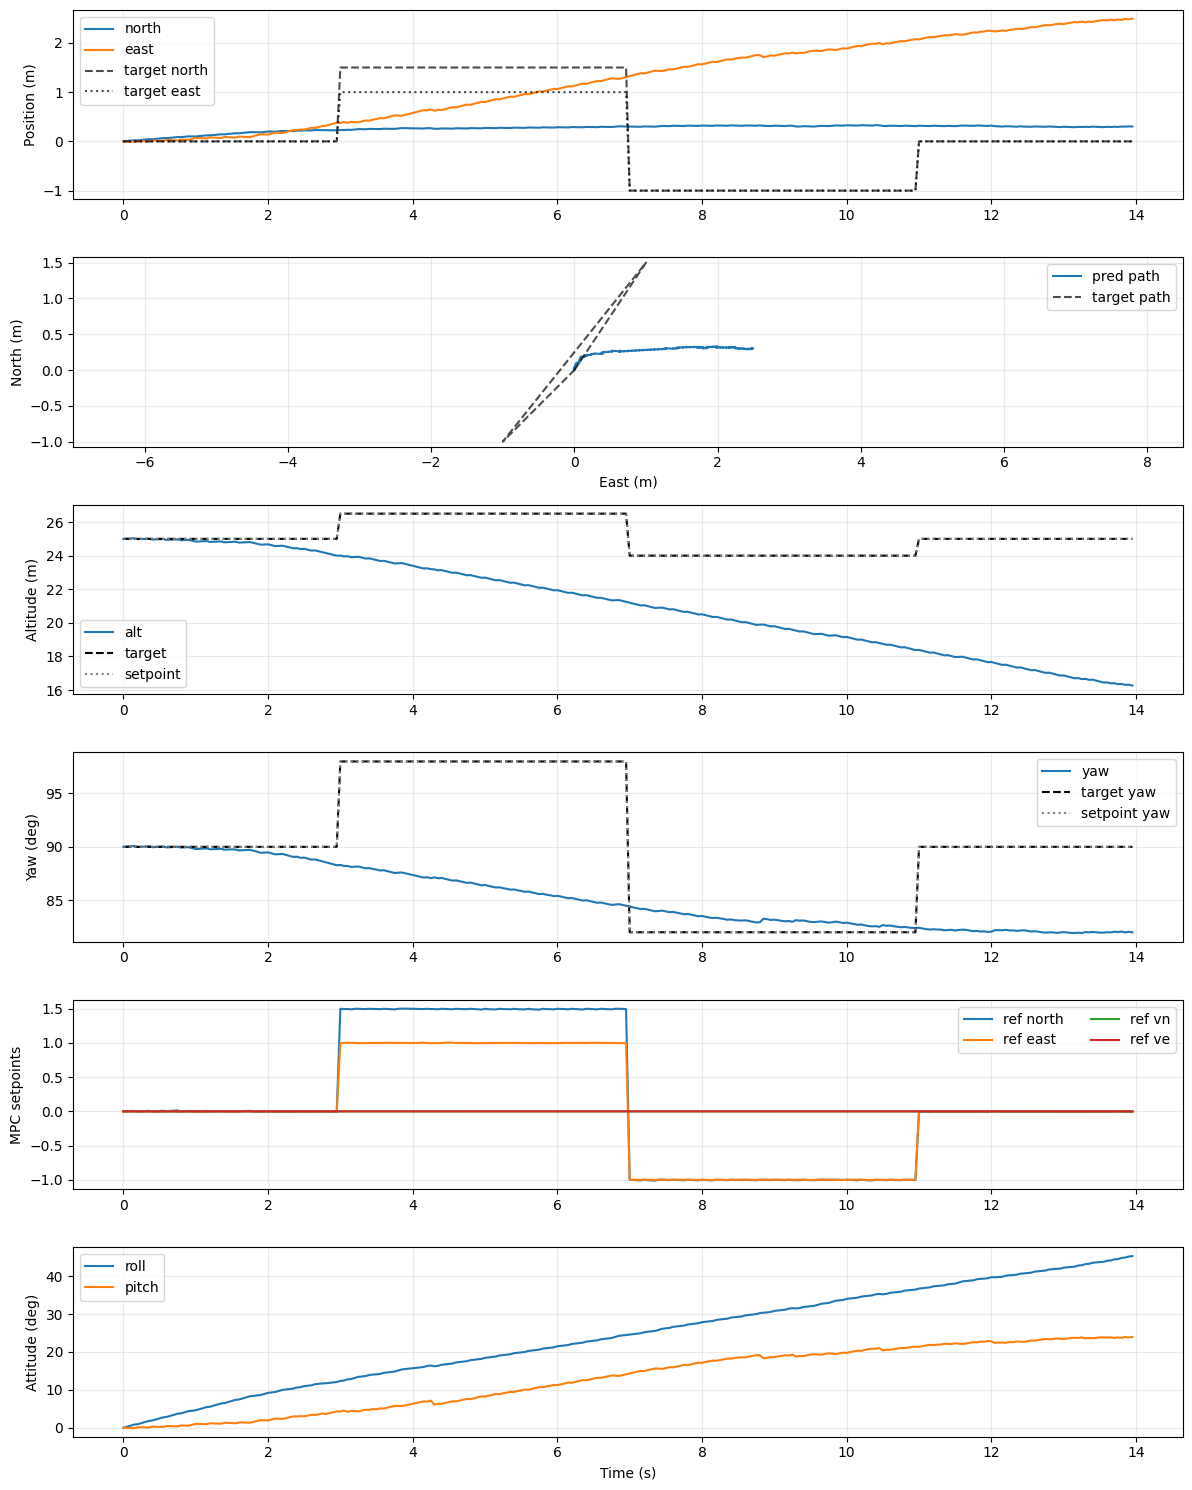

In [15]:
def compute_mpc_metrics(log):
    pos_err = np.sqrt((log['north_m'] - log['target_north_m']) ** 2 + (log['east_m'] - log['target_east_m']) ** 2)
    alt_err = log['alt_m'] - log['target_alt_m']
    yaw_err = wrap_deg_np(log['yaw_deg'].to_numpy() - (90.0 + log['target_yaw_offset_deg'].to_numpy()))
    return pd.DataFrame([{
        'pos_rmse_m': float(np.sqrt(np.mean(pos_err ** 2))),
        'pos_final_err_m': float(pos_err.iloc[-1]),
        'alt_rmse_m': float(np.sqrt(np.mean(alt_err ** 2))),
        'alt_final_err_m': float(alt_err.iloc[-1]),
        'yaw_rmse_deg': float(np.sqrt(np.mean(yaw_err ** 2))),
        'yaw_final_err_deg': float(yaw_err[-1]),
        'max_abs_roll_deg': float(np.max(np.abs(log['roll_deg']))),
        'max_abs_pitch_deg': float(np.max(np.abs(log['pitch_deg']))),
    }])

mpc_metrics = compute_mpc_metrics(mpc_log)
display(mpc_metrics)

fig, axes = plt.subplots(6, 1, figsize=(12, 15), sharex=False)
t = mpc_log['time_s']
axes[0].plot(t, mpc_log['north_m'], label='north')
axes[0].plot(t, mpc_log['east_m'], label='east')
axes[0].plot(t, mpc_log['target_north_m'], 'k--', alpha=0.7, label='target north')
axes[0].plot(t, mpc_log['target_east_m'], 'k:', alpha=0.7, label='target east')
axes[0].set_ylabel('Position (m)')
axes[0].legend()

axes[1].plot(mpc_log['east_m'], mpc_log['north_m'], label='pred path')
axes[1].plot(mpc_log['target_east_m'], mpc_log['target_north_m'], 'k--', alpha=0.7, label='target path')
axes[1].set_ylabel('North (m)')
axes[1].set_xlabel('East (m)')
axes[1].axis('equal')
axes[1].legend()

axes[2].plot(t, mpc_log['alt_m'], label='alt')
axes[2].plot(t, mpc_log['target_alt_m'], 'k--', label='target')
axes[2].plot(t, mpc_log['ref_alt_m'], '0.5', ls=':', label='setpoint')
axes[2].set_ylabel('Altitude (m)')
axes[2].legend()

axes[3].plot(t, mpc_log['yaw_deg'], label='yaw')
axes[3].plot(t, 90.0 + mpc_log['target_yaw_offset_deg'], 'k--', label='target yaw')
axes[3].plot(t, 90.0 + mpc_log['ref_yaw_offset_deg'], '0.5', ls=':', label='setpoint yaw')
axes[3].set_ylabel('Yaw (deg)')
axes[3].legend()

axes[4].plot(t, mpc_log['ref_north_m'], label='ref north')
axes[4].plot(t, mpc_log['ref_east_m'], label='ref east')
axes[4].plot(t, mpc_log['ref_vn_m_s'], label='ref vn')
axes[4].plot(t, mpc_log['ref_ve_m_s'], label='ref ve')
axes[4].set_ylabel('MPC setpoints')
axes[4].legend(ncol=2)

axes[5].plot(t, mpc_log['roll_deg'], label='roll')
axes[5].plot(t, mpc_log['pitch_deg'], label='pitch')
axes[5].set_ylabel('Attitude (deg)')
axes[5].set_xlabel('Time (s)')
axes[5].legend()
for ax in axes:
    ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()


In [16]:
if Path('/content/drive/MyDrive').exists():
    SAVE_ROOT = Path('/content/drive/MyDrive/Colab Result/PINN_MPC/px4_phase1_closed_loop_pinn_mpc_v2_position_state')
else:
    SAVE_ROOT = Path('/content/px4_phase1_closed_loop_pinn_mpc_v2_position_state')
SAVE_DIR = SAVE_ROOT / time.strftime('%Y%m%d_%H%M%S')
SAVE_DIR.mkdir(parents=True, exist_ok=True)
mpc_log.to_csv(SAVE_DIR / 'pinn_mpc_learned_model_log.csv', index=False)
mpc_metrics.to_csv(SAVE_DIR / 'pinn_mpc_learned_model_metrics.csv', index=False)
fig.savefig(SAVE_DIR / 'pinn_mpc_learned_model_response.png', dpi=160, bbox_inches='tight')
with open(SAVE_DIR / 'config.json', 'w') as f:
    json.dump({
        'revision': NOTEBOOK_REVISION,
        'checkpoint': str(CKPT_PATH),
        'horizon': MPC_HORIZON,
        'samples': MPC_SAMPLES,
        'elites': MPC_ELITES,
        'iters': MPC_ITERS,
        'control_interval_steps': CONTROL_INTERVAL_STEPS,
        'cost': COST,
    }, f, indent=2)
print('saved:', SAVE_DIR)


saved: /content/drive/MyDrive/Colab Result/PINN_MPC/px4_phase1_closed_loop_pinn_mpc_v2_position_state/20260509_232712
